# Módulo 8. Validación temporal del modelo

En este módulo se evalúa la capacidad predictiva del modelo en un escenario más cercano a una aplicación real.

A diferencia de la división aleatoria utilizada durante el entrenamiento inicial, la evaluación se realiza separando los datos cronológicamente. De esta manera, el modelo se entrena utilizando únicamente información de años anteriores y posteriormente realiza predicciones sobre un año futuro.

Este procedimiento permite verificar la capacidad de generalización del modelo y constituye una aproximación más realista a un sistema de alerta temprana para la deserción escolar.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
PROJECT_ROOT = Path.cwd().parent

df = pd.read_csv(
    PROJECT_ROOT /
    "data" /
    "processed" /
    "dataset_modelado.csv"
)

print(df.shape)

df.head()

(15707, 85)


,AÑO,CÓDIGO_MUNICIPIO,MUNICIPIO,CÓDIGO_DEPARTAMENTO,DEPARTAMENTO,CÓDIGO_ETC,ETC,POBLACIÓN_5_16,TASA_MATRICULACIÓN_5_16,COBERTURA_NETA,...,REPITENCIA_MEDIA_ETC,BENEFICIARIOS_PAE,BRECHA_COBERTURA,BRECHA_APROBACION,INDICE_EFICIENCIA,PRESION_SISTEMA,DIGITALIZADO,TAM_GRUPO_NORMALIZADO,PESO_MUNICIPIO_ETC,PANDEMIA
0,2024,5004,Abriaquí,5,Antioquia,3758.0,Antioquia (ETC),499.0,56.11,56.11,...,3.35,NaN,5.81,99.36,11.418099,8.893245,0,NaN,0.001007,0
1,2024,15204,Cómbita,15,Boyacá,3769.0,Boyacá (ETC),1862.0,95.33,95.33,...,3.21,NaN,96.18,91.52,6.821739,19.532151,0,NaN,0.011952,0
2,2024,99773,Cumaribo,99,Vichada,3832.0,Vichada (ETC),25239.0,50.70,50.70,...,4.08,NaN,7.04,64.06,1.940284,497.810651,0,NaN,0.750245,0
3,2024,99624,Santa Rosalía,99,Vichada,3832.0,Vichada (ETC),1157.0,81.42,81.42,...,4.08,NaN,9.16,78.44,3.176015,14.210268,0,NaN,0.034393,0
4,2024,99524,La Primavera,99,Vichada,3832.0,Vichada (ETC),2645.0,90.96,90.96,...,4.08,NaN,8.17,77.18,3.169123,29.078716,0,NaN,0.078624,0


In [3]:
# Variable objetivo
y = df["DESERCIÓN"]

columnas_excluir = [
    "DESERCIÓN",

    "MUNICIPIO",
    "DEPARTAMENTO",
    "ETC",

    "CÓDIGO_MUNICIPIO",
    "CÓDIGO_DEPARTAMENTO",

    "DESERCIÓN_TRANSICIÓN",
    "DESERCIÓN_PRIMARIA",
    "DESERCIÓN_SECUNDARIA",
    "DESERCIÓN_MEDIA",

    "DESERCIÓN_ETC",
    "DESERCIÓN_TRANSICIÓN_ETC",
    "DESERCIÓN_PRIMARIA_ETC",
    "DESERCIÓN_SECUNDARIA_ETC",
    "DESERCIÓN_MEDIA_ETC"
]

X = df.drop(columns=columnas_excluir)

# Eliminar columna textual restante
if "ETC_ETC" in X.columns:
    X = X.drop(columns=["ETC_ETC"])

# Imputación
X = X.fillna(X.median(numeric_only=True))

# Eliminar registros sin variable objetivo
mask = y.notna()

X = X.loc[mask].reset_index(drop=True)
y = y.loc[mask].reset_index(drop=True)

# Mantener el dataframe alineado
df = df.loc[mask].reset_index(drop=True)

print(X.shape)

(15565, 69)


## 8.1 Validación temporal mediante ventana expansiva

Con el propósito de evaluar la capacidad de generalización del modelo en un escenario real, se implementa una validación temporal basada en una ventana expansiva.

En cada iteración, el modelo se entrena utilizando todos los datos disponibles hasta un determinado año y posteriormente se evalúa sobre el año inmediatamente siguiente.

Este procedimiento permite simular el comportamiento que tendría un sistema de alerta temprana, donde únicamente se dispone de información histórica para realizar predicciones sobre el futuro.

In [4]:
# ===============================
# VALIDACIÓN TEMPORAL
# ===============================

import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ------------------------------
# Variable objetivo
# ------------------------------

y = df["DESERCIÓN"]

columnas_excluir = [
    "DESERCIÓN",
    "MUNICIPIO",
    "DEPARTAMENTO",
    "ETC",
    "CÓDIGO_MUNICIPIO",
    "CÓDIGO_DEPARTAMENTO",

    "DESERCIÓN_TRANSICIÓN",
    "DESERCIÓN_PRIMARIA",
    "DESERCIÓN_SECUNDARIA",
    "DESERCIÓN_MEDIA",

    "DESERCIÓN_ETC",
    "DESERCIÓN_TRANSICIÓN_ETC",
    "DESERCIÓN_PRIMARIA_ETC",
    "DESERCIÓN_SECUNDARIA_ETC",
    "DESERCIÓN_MEDIA_ETC"
]

X = df.drop(columns=columnas_excluir)

# Eliminar columna de texto restante
if "ETC_ETC" in X.columns:
    X = X.drop(columns=["ETC_ETC"])

# Imputación
X = X.fillna(X.median(numeric_only=True))

# Eliminar filas sin variable objetivo
mask = y.notna()

X = X.loc[mask].reset_index(drop=True)
y = y.loc[mask].reset_index(drop=True)
df_validacion = df.loc[mask].reset_index(drop=True)

# ===============================
# VALIDACIÓN TEMPORAL
# ===============================

resultados = []

años = sorted(df_validacion["AÑO"].unique())

for año_prueba in años[1:]:

    X_train = X[df_validacion["AÑO"] < año_prueba]
    y_train = y[df_validacion["AÑO"] < año_prueba]

    X_test = X[df_validacion["AÑO"] == año_prueba]
    y_test = y[df_validacion["AÑO"] == año_prueba]

    # Saltar años sin datos suficientes
    if len(X_train) == 0 or len(X_test) == 0:
        continue

    modelo = RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )

    modelo.fit(X_train, y_train)

    y_pred = modelo.predict(X_test)

    resultados.append({
        "Año": año_prueba,
        "Entrenamiento": len(X_train),
        "Prueba": len(X_test),
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R²": r2_score(y_test, y_pred)
    })

# ===============================
# RESULTADOS
# ===============================

resultados = pd.DataFrame(resultados)

print(resultados.round(3))

     Año  Entrenamiento  Prueba    MAE   RMSE     R²
0   2012           1060    1097  0.447  0.828  0.871
1   2013           2157    1104  0.238  0.512  0.936
2   2014           3261    1110  0.131  0.395  0.954
3   2015           4371    1106  0.213  0.448  0.949
4   2016           5477    1120  0.178  0.520  0.945
5   2017           6597    1120  0.131  0.413  0.954
6   2018           7717    1120  0.128  0.404  0.953
7   2019           8837    1121  0.124  0.487  0.920
8   2020           9958    1121  0.339  0.859  0.871
9   2021          11079    1122  0.235  0.792  0.913
10  2022          12201    1121  0.147  0.384  0.962
11  2023          13322    1121  0.109  0.253  0.982
12  2024          14443    1122  0.096  0.202  0.987


## 8.2 Evolución del desempeño del modelo

Con el fin de analizar la estabilidad del modelo a lo largo del tiempo, se representa gráficamente la evolución del coeficiente de determinación (R²) obtenido para cada año de evaluación.

Esta visualización permite identificar periodos en los cuales la capacidad predictiva del modelo disminuye o mejora, facilitando la interpretación de eventos externos que pudieron afectar el comportamiento de la deserción escolar.

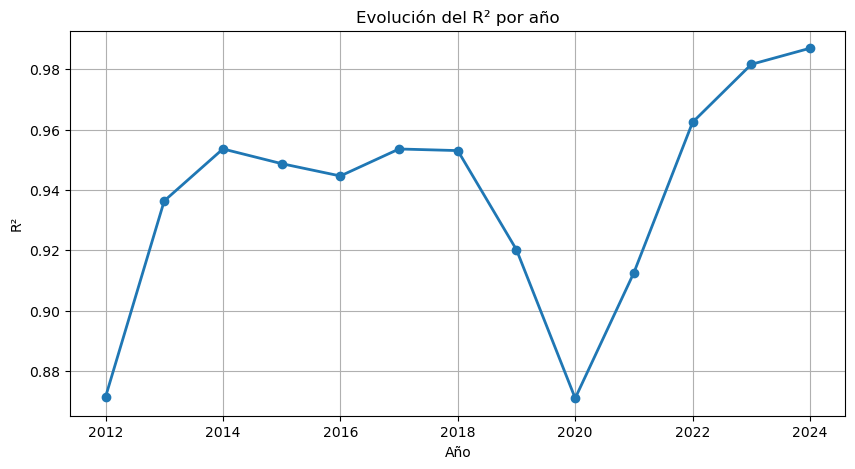

In [5]:
plt.figure(figsize=(10,5))

plt.plot(
    resultados["Año"],
    resultados["R²"],
    marker="o",
    linewidth=2
)

plt.title("Evolución del R² por año")

plt.xlabel("Año")

plt.ylabel("R²")

plt.grid(True)

plt.show()

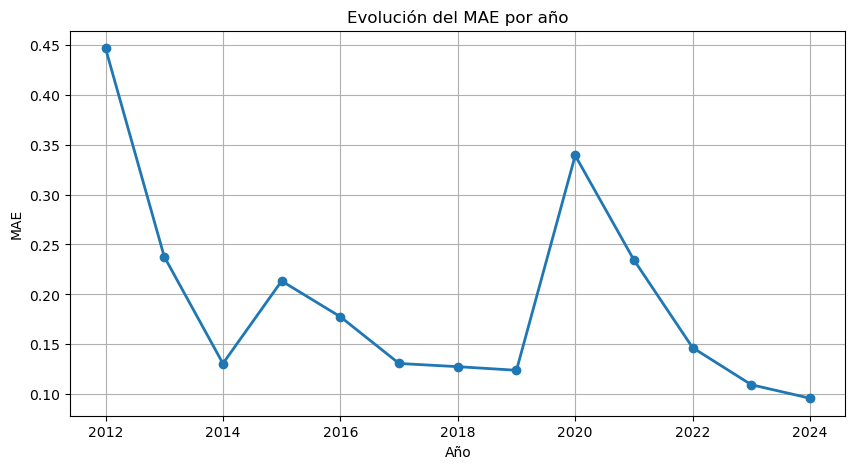

In [6]:
plt.figure(figsize=(10,5))

plt.plot(
    resultados["Año"],
    resultados["MAE"],
    marker="o",
    linewidth=2
)

plt.title("Evolución del MAE por año")

plt.xlabel("Año")

plt.ylabel("MAE")

plt.grid(True)

plt.show()

## 8.3 Comparación entre valores reales y predichos

Con el fin de ilustrar el comportamiento del modelo, se comparan las tasas reales de deserción escolar con las predicciones obtenidas para el año 2024.

Esta comparación permite evaluar el error cometido en municipios específicos y facilita una interpretación más intuitiva del desempeño alcanzado por el modelo.

In [7]:
# ===============================
# Predicciones para el año 2024
# ===============================

año = 2024

# Datos de entrenamiento
X_train = X[df_validacion["AÑO"] < año]
y_train = y[df_validacion["AÑO"] < año]

# Datos de prueba
X_test = X[df_validacion["AÑO"] == año]
y_test = y[df_validacion["AÑO"] == año]

# Entrenar modelo
modelo = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

modelo.fit(X_train, y_train)

# Predicciones
y_pred = modelo.predict(X_test)

# Tabla de resultados
comparacion = pd.DataFrame({
    "Municipio": df_validacion.loc[df_validacion["AÑO"] == año, "MUNICIPIO"].values,
    "Departamento": df_validacion.loc[df_validacion["AÑO"] == año, "DEPARTAMENTO"].values,
    "Real": y_test.values,
    "Predicción": y_pred
})

comparacion["Error"] = abs(
    comparacion["Real"] - comparacion["Predicción"]
)

comparacion.head(20)

,Municipio,Departamento,Real,Predicción,Error
0,Abriaquí,Antioquia,0.00,0.158900,0.158900
1,Cómbita,Boyacá,3.24,3.222000,0.018000
2,Cumaribo,Vichada,5.50,5.715300,0.215300
3,Santa Rosalía,Vichada,6.30,6.296200,0.003800
4,La Primavera,Vichada,5.16,5.204800,0.044800
5,Puerto Carreño,Vichada,8.45,8.467100,0.017100
6,Yavaraté,Vaupés,8.39,9.410800,1.020800
7,Papunaua,Vaupés,0.00,0.846417,0.846417
8,Taraira,Vaupés,0.00,0.000000,0.000000
9,Pacoa,Vaupés,7.83,7.640200,0.189800


### Municipios con mayor error de predicción

A continuación se presentan los municipios en los cuales el modelo registró las mayores diferencias entre la tasa real y la tasa predicha de deserción escolar.

Este análisis permite identificar los casos más difíciles de modelar y constituye una herramienta útil para orientar futuras mejoras del sistema predictivo.

In [8]:
comparacion.sort_values(
    by="Error",
    ascending=False
).head(15)

,Municipio,Departamento,Real,Predicción,Error
20,Puerto Colombia,Guainía,2.83,5.754800,2.924800
425,Mapiripán,Meta,12.29,10.649500,1.640500
802,Ráquira,Boyacá,3.18,4.633100,1.453100
772,Morelia,Caquetá,10.28,8.831100,1.448900
44,Puerto Guzmán,Putumayo,11.50,10.432600,1.067400
515,Baraya,Huila,4.19,3.157700,1.032300
32,La Chorrera,Amazonas,14.81,13.781300,1.028700
6,Yavaraté,Vaupés,8.39,9.410800,1.020800
838,Sativasur,Boyacá,0.00,0.867500,0.867500
84,Toro,Valle del Cauca,6.11,6.972000,0.862000


### Relación entre valores reales y predicciones

El siguiente gráfico compara las predicciones generadas por el modelo con los valores reales observados para el año 2024.

Mientras más próximos se encuentren los puntos a la línea diagonal, mayor será la precisión alcanzada por el modelo.

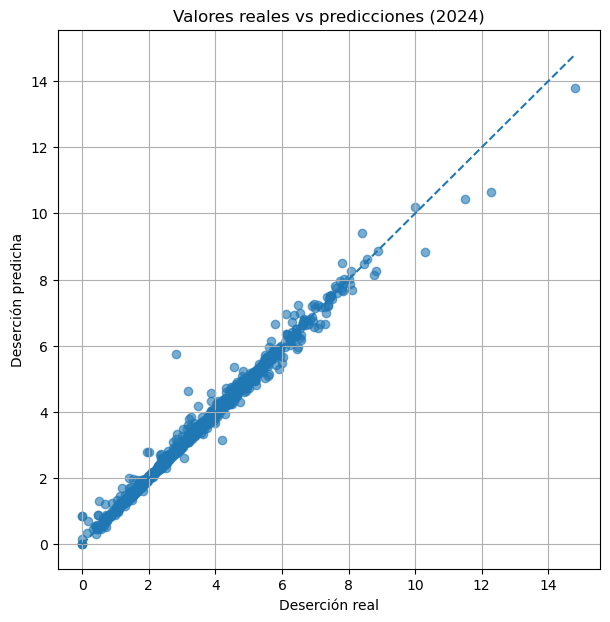

In [9]:
plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

# Línea ideal
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "--"
)

plt.xlabel("Deserción real")
plt.ylabel("Deserción predicha")

plt.title("Valores reales vs predicciones (2024)")

plt.grid(True)

plt.show()

# 8.4 Conclusiones de la validación temporal

La validación temporal permitió evaluar el comportamiento del modelo en un escenario más cercano a una aplicación real, donde únicamente se dispone de información histórica para realizar predicciones sobre años futuros.

Los resultados muestran que el modelo mantiene un desempeño elevado durante todo el periodo analizado, alcanzando valores de R² superiores a 0.94 en la mayoría de los años y obteniendo su mejor desempeño en 2024 con un R² de 0.987.

Durante los años 2020 y 2021 se observó una disminución temporal de la capacidad predictiva, comportamiento que coincide con las alteraciones generadas por la pandemia de COVID-19 sobre el sistema educativo colombiano. Posteriormente, el modelo recupera progresivamente su desempeño, alcanzando nuevamente altos niveles de precisión.

La comparación entre las tasas reales y las predicciones municipales evidencia que la mayoría de los municipios presentan errores bajos y que las predicciones siguen de forma consistente la tendencia observada en los datos reales. Los mayores errores se concentran en municipios con condiciones territoriales particulares, lo que sugiere la existencia de factores sociales, económicos o geográficos que no están representados en las variables utilizadas para el entrenamiento.

En conjunto, los resultados obtenidos indican que el modelo desarrollado posee una adecuada capacidad de generalización y constituye una herramienta con potencial para apoyar sistemas de alerta temprana orientados a la identificación de territorios con mayor riesgo de deserción escolar.

In [10]:
import joblib
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

# Crear carpeta si no existe
(PROJECT_ROOT / "models").mkdir(exist_ok=True)

# Guardar modelo
joblib.dump(
    modelo,
    PROJECT_ROOT / "models" / "random_forest_desercion.pkl"
)

print("✅ Modelo guardado correctamente.")

✅ Modelo guardado correctamente.
